In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/balanced_cleaned_reviews.csv")

In [ ]:
df.head()

In [6]:
df['Sentiment'].value_counts()

Sentiment
Positive    17936
Negative    14349
Neutral     10468
Name: count, dtype: int64

C:\Users\Nupoor\AppData\Local\Temp\ipykernel_29428\568090597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


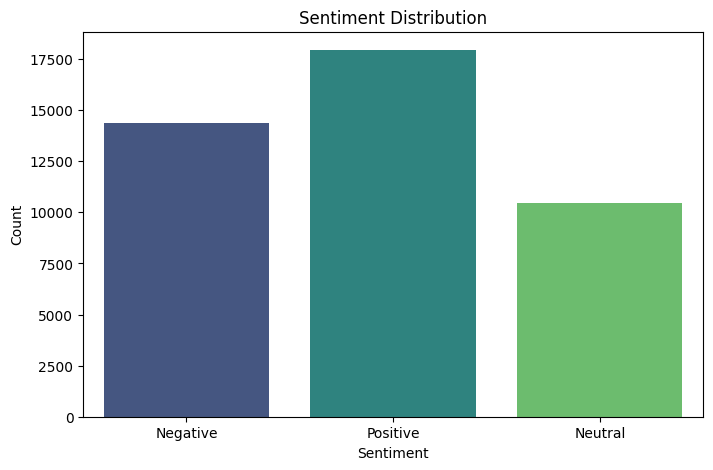

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df,
    palette='viridis'
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [8]:
sentiment_counts = df['Sentiment'].value_counts().sort_index().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

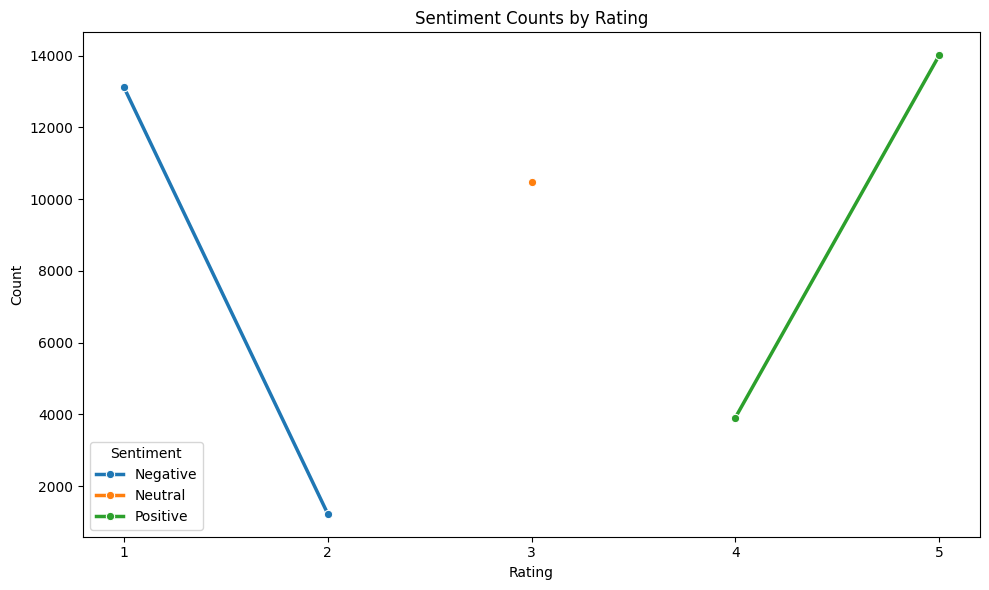

In [11]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

sentiment_rating = (
    df.dropna(subset=['Rating'])
      .groupby(['Rating', 'Sentiment'])
      .size()
      .reset_index(name='Count')
      .sort_values(['Rating', 'Sentiment'])
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=sentiment_rating,
    x='Rating',
    y='Count',
    hue='Sentiment',
    marker='o',
    linewidth=2.5
)

plt.title('Sentiment Counts by Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(sorted(sentiment_rating['Rating'].unique()))
plt.tight_layout()
plt.show()